<a href="https://colab.research.google.com/github/deorakamlesh07-droid/Celabal_CEI/blob/main/Week2_kamleshdeora.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 Week 2 Assignment: End-to-End Machine Learning Pipeline for Sales/Price Forecasting

Designed and implemented an end-to-end machine learning pipeline on sales/price data covering data preprocessing, exploratory data analysis (EDA), feature engineering, regression modeling, hyperparameter tuning, and time series forecasting.


In [3]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
import joblib
import statsmodels.api as sm
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 200)
sns.set_theme(style='whitegrid')


In [4]:
# Dataset path (absolute provided + fallback to local file in CWD)
DATA_PATH = r"/content/tesla_deliveries_dataset_2015_2025.csv"
if not os.path.exists(DATA_PATH):
    DATA_PATH = "tesla_deliveries_dataset_2015_2025.csv"

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()


Shape: (2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [5]:
# Basic schema checks
print(df.dtypes)
print("\\nMissing values per column:\\n", df.isna().sum().sort_values(ascending=False))

# Create a monthly datetime index from Year/Month
required = {"Year", "Month"}
if not required.issubset(df.columns):
    raise ValueError(f"Expected columns {required} for time index.")

df["Date"] = pd.to_datetime(dict(year=df["Year"], month=df["Month"], day=1))

# Sort for time-aware features
sort_cols = ["Region", "Model", "Date"] if {"Region", "Model"}.issubset(df.columns) else ["Date"]
df = df.sort_values(sort_cols).reset_index(drop=True)

df[["Year", "Month", "Date"]].head()


Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64
dtype: object
\nMissing values per column:\n Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


,Year,Month,Date
0,2015,1,2015-01-01
1,2015,2,2015-02-01
2,2015,3,2015-03-01
3,2015,4,2015-04-01
4,2015,5,2015-05-01


## 1) Quick EDA

We'll inspect distributions, seasonality, and relationships with price/production.

In [6]:
# Summary stats
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)

# Numeric summary
(df[num_cols]
 .describe(percentiles=[.01,.05,.25,.5,.75,.95,.99])
 .T
 .sort_values('mean', ascending=False)
 .head(20))


Numeric columns: ['Year', 'Month', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations']
Categorical columns: ['Region', 'Model', 'Source_Type']


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
Avg_Price_USD,2640.0,84907.340330,20123.258036,50003.70,50781.2345,53511.7225,67726.365,85058.510,102373.0425,116544.3495,119249.2584,119965.36
Production_Units,2640.0,10655.847348,4260.600858,50.00,1100.8300,3569.9000,7828.250,10546.500,13469.0000,17675.2000,20826.4200,28939.00
Estimated_Deliveries,2640.0,9922.199621,3935.950093,48.00,1037.5500,3249.3500,7292.000,9857.000,12510.2500,16359.4500,19265.2400,25704.00
Charging_Stations,2640.0,8932.133712,3469.565883,3002.00,3128.7800,3621.9500,5897.750,8901.500,11938.0000,14337.1500,14904.2200,14996.00
Year,2640.0,2020.000000,3.162877,2015.00,2015.0000,2015.0000,2017.000,2020.000,2023.0000,2025.0000,2025.0000,2025.00
CO2_Saved_tons,2640.0,744.076989,353.221224,3.07,77.3988,233.0905,499.620,699.515,943.7650,1389.5570,1740.5623,2548.55
Range_km,2640.0,500.257576,120.868549,330.00,331.0000,336.0000,418.000,470.000,586.2500,704.0000,717.0000,719.00
Battery_Capacity_kWh,2640.0,87.059470,20.836265,60.00,60.0000,60.0000,75.000,82.000,100.0000,120.0000,120.0000,120.00
Month,2640.0,6.500000,3.452707,1.00,1.0000,1.0000,3.750,6.500,9.2500,12.0000,12.0000,12.00


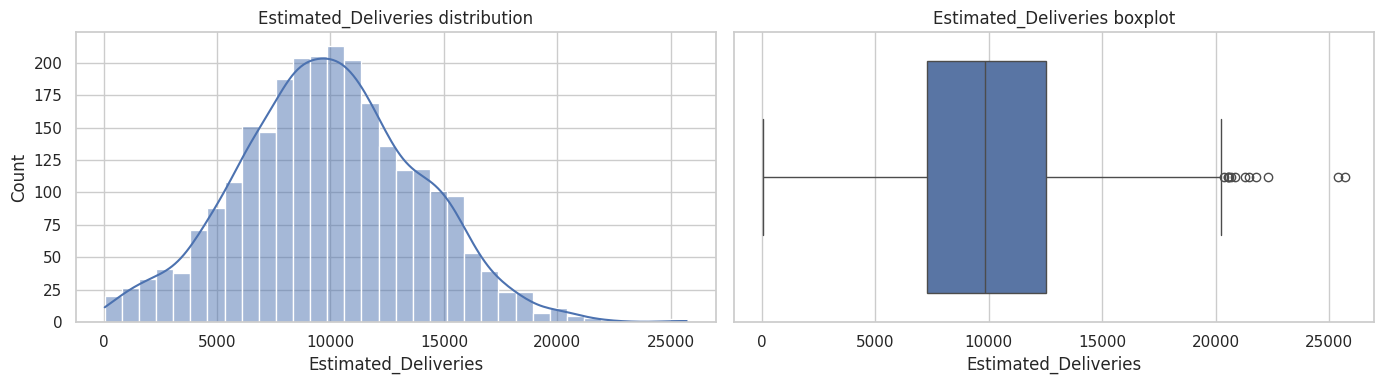

In [7]:
# Target distribution
TARGET = "Estimated_Deliveries"
if TARGET not in df.columns:
    raise ValueError(f"Target column '{TARGET}' not found.")

fig, ax = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df[TARGET], kde=True, ax=ax[0])
ax[0].set_title(f"{TARGET} distribution")

sns.boxplot(x=df[TARGET], ax=ax[1])
ax[1].set_title(f"{TARGET} boxplot")

plt.tight_layout()
plt.show()


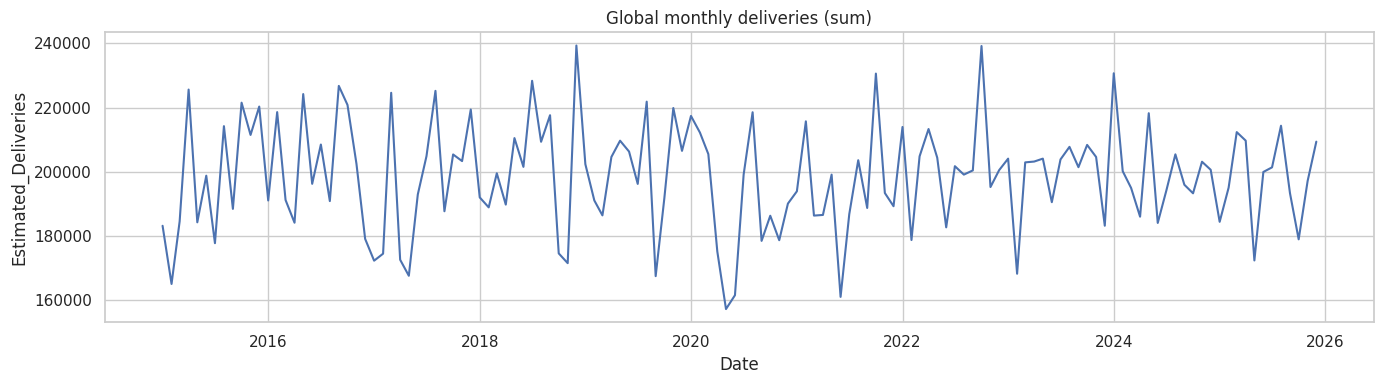

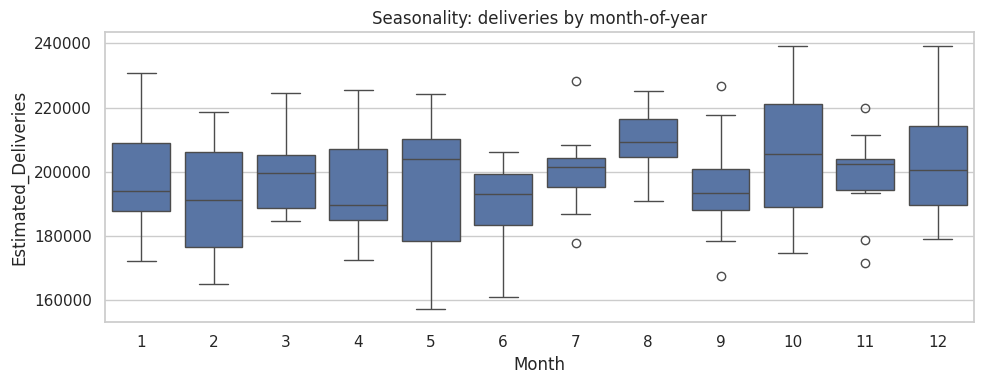

In [8]:
# Monthly global deliveries trend
monthly = (df.groupby('Date', as_index=False)[TARGET]
           .sum()
           .sort_values('Date'))

plt.figure(figsize=(14, 4))
plt.plot(monthly['Date'], monthly[TARGET])
plt.title('Global monthly deliveries (sum)')
plt.xlabel('Date')
plt.ylabel(TARGET)
plt.tight_layout()
plt.show()

# Seasonality by month-of-year
plt.figure(figsize=(10, 4))
sns.boxplot(x=monthly['Date'].dt.month, y=monthly[TARGET])
plt.title('Seasonality: deliveries by month-of-year')
plt.xlabel('Month')
plt.ylabel(TARGET)
plt.tight_layout()
plt.show()


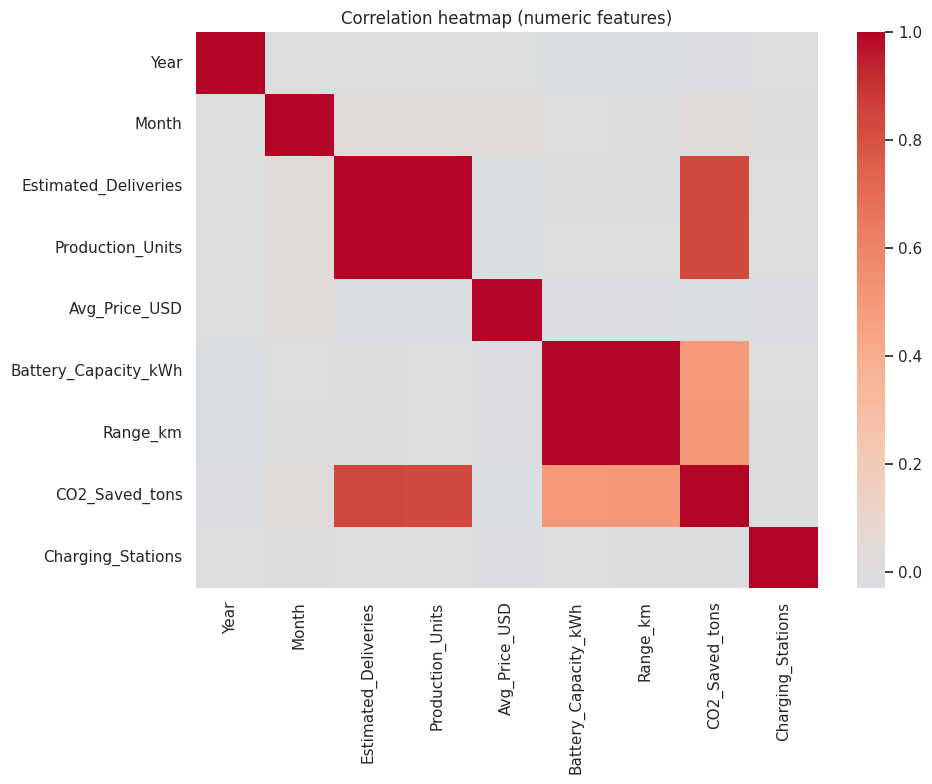

In [19]:
# Correlations among numeric features (global)
# (Use a sample if very large)
plot_df = df[num_cols].copy()

corr = plot_df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation heatmap (numeric features)')
plt.tight_layout()
plt.show()


## 2) Feature Engineering (Time-aware)

We create group-wise lag features and rolling statistics by `(Region, Model)`.
These are useful for demand forecasting / sales modeling.

In [10]:
# Group keys for lag/rolling features
GROUP_KEYS = ["Region", "Model"]
if not set(GROUP_KEYS).issubset(df.columns):
    GROUP_KEYS = []

# Helper: safe groupby
if GROUP_KEYS:
    g = df.groupby(GROUP_KEYS, sort=False)
else:
    g = [(None, df)]

# Lags and rolling means for deliveries
for lag in [1, 3, 6, 12]:
    col = f"{TARGET}_lag{lag}"
    if GROUP_KEYS:
        df[col] = df.groupby(GROUP_KEYS)[TARGET].shift(lag)
    else:
        df[col] = df[TARGET].shift(lag)

for win in [3, 6, 12]:
    col = f"{TARGET}_rollmean{win}"
    if GROUP_KEYS:
        df[col] = (df.groupby(GROUP_KEYS)[TARGET]
                   .shift(1)
                   .rolling(win)
                   .mean())
    else:
        df[col] = df[TARGET].shift(1).rolling(win).mean()

month = df['Date'].dt.month


df['month_sin'] = np.sin(2*np.pi*month/12)
df['month_cos'] = np.cos(2*np.pi*month/12)

df['quarter'] = df['Date'].dt.quarter

# Trend index (global ordering by Date)
df['time_idx'] = (df['Date'].astype('int64') // 10**9)  # seconds since epoch

engineered = [c for c in df.columns if 'lag' in c or 'rollmean' in c] + ['month_sin','month_cos','quarter','time_idx']
engineered = [c for c in engineered if c in df.columns]
print('Engineered feature count:', len(engineered))
df[['Date'] + (GROUP_KEYS if GROUP_KEYS else []) + engineered].head(10)


Engineered feature count: 11


,Date,Region,Model,Estimated_Deliveries_lag1,Estimated_Deliveries_lag3,Estimated_Deliveries_lag6,Estimated_Deliveries_lag12,Estimated_Deliveries_rollmean3,Estimated_Deliveries_rollmean6,Estimated_Deliveries_rollmean12,month_sin,month_cos,quarter,time_idx
0,2015-01-01,Asia,Cybertruck,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000e-01,8.660254e-01,1,1420070400
1,2015-02-01,Asia,Cybertruck,11325.0,NaN,NaN,NaN,NaN,NaN,NaN,8.660254e-01,5.000000e-01,1,1422748800
2,2015-03-01,Asia,Cybertruck,13254.0,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e+00,6.123234e-17,1,1425168000
3,2015-04-01,Asia,Cybertruck,10257.0,11325.0,NaN,NaN,11612.000000,NaN,NaN,8.660254e-01,-5.000000e-01,2,1427846400
4,2015-05-01,Asia,Cybertruck,15221.0,13254.0,NaN,NaN,12910.666667,NaN,NaN,5.000000e-01,-8.660254e-01,2,1430438400
5,2015-06-01,Asia,Cybertruck,6406.0,10257.0,NaN,NaN,10628.000000,NaN,NaN,1.224647e-16,-1.000000e+00,2,1433116800
6,2015-07-01,Asia,Cybertruck,7201.0,15221.0,11325.0,NaN,9609.333333,10610.666667,NaN,-5.000000e-01,-8.660254e-01,3,1435708800
7,2015-08-01,Asia,Cybertruck,113.0,6406.0,13254.0,NaN,4573.333333,8742.000000,NaN,-8.660254e-01,-5.000000e-01,3,1438387200
8,2015-09-01,Asia,Cybertruck,10222.0,7201.0,10257.0,NaN,5845.333333,8236.666667,NaN,-1.000000e+00,-1.836970e-16,3,1441065600
9,2015-10-01,Asia,Cybertruck,10844.0,113.0,15221.0,NaN,7059.666667,8334.500000,NaN,-8.660254e-01,5.000000e-01,4,1443657600


## 3) Train/Test Split (Time-based)

We avoid random splitting because this is time series-like data.
We'll hold out the last **12 months** as the test set.

In [11]:
# Build feature matrix
TARGET = 'Estimated_Deliveries'

drop_cols = [TARGET]

LEAKAGE_COLS = ['production_minus_deliveries']
drop_cols += [c for c in LEAKAGE_COLS if c in df.columns]

exclude = set(['Date'])

feature_cols = [c for c in df.columns if c not in drop_cols and c not in exclude]


unique_months = np.sort(df['Date'].unique())
if len(unique_months) < 24:

    cutoff = unique_months[int(len(unique_months)*0.8)]
else:
    cutoff = unique_months[-12]

train_mask = df['Date'] < cutoff

df_train = df[train_mask].copy()
df_test  = df[~train_mask].copy()

print('Cutoff date:', pd.to_datetime(cutoff).date())
print('Train rows:', df_train.shape[0], 'Test rows:', df_test.shape[0])

X_train = df_train[feature_cols]
y_train = df_train[TARGET]
X_test  = df_test[feature_cols]
y_test  = df_test[TARGET]

X_train.head()


Cutoff date: 2025-01-01
Train rows: 2400 Test rows: 240


,Year,Month,Region,Model,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Estimated_Deliveries_lag1,Estimated_Deliveries_lag3,Estimated_Deliveries_lag6,Estimated_Deliveries_lag12,Estimated_Deliveries_rollmean3,Estimated_Deliveries_rollmean6,Estimated_Deliveries_rollmean12,month_sin,month_cos,quarter,time_idx
0,2015,1,Asia,Cybertruck,11887,54449.08,60,339,575.88,Estimated (Region),6902,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.500000,8.660254e-01,1,1420070400
1,2015,2,Asia,Cybertruck,14878,88864.06,75,432,858.86,Estimated (Region),5902,11325.0,NaN,NaN,NaN,NaN,NaN,NaN,0.866025,5.000000e-01,1,1422748800
2,2015,3,Asia,Cybertruck,11441,65107.47,100,581,893.90,Interpolated (Month),4024,13254.0,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,6.123234e-17,1,1425168000
3,2015,4,Asia,Cybertruck,15951,112686.63,60,341,778.55,Estimated (Region),3130,10257.0,11325.0,NaN,NaN,11612.000000,NaN,NaN,0.866025,-5.000000e-01,2,1427846400
4,2015,5,Asia,Cybertruck,7281,107577.61,75,448,430.48,Interpolated (Month),11708,15221.0,13254.0,NaN,NaN,12910.666667,NaN,NaN,0.500000,-8.660254e-01,2,1430438400


## 4) Regression Modeling

We'll train a few models:
- **Ridge** (strong baseline)
- **RandomForestRegressor** (nonlinear baseline)
- **HistGradientBoostingRegressor** (fast boosting)

Preprocessing:
- Numeric: median imputation
- Categorical: most_frequent + one-hot


In [12]:
# Identify column types
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in X_train.columns if c not in numeric_features]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ],
    remainder='drop'
)

def eval_regression(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(1.0, np.abs(y_true))))
    r2 = r2_score(y_true, y_pred)
    return {'model': name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}

models = {
    'ridge': Ridge(random_state=42),
    'rf': RandomForestRegressor(
        n_estimators=400,
        random_state=42,
        n_jobs=-1,
        max_depth=None
    ),
    'hgb': HistGradientBoostingRegressor(random_state=42),
}

results = []
trained = {}

for name, estimator in models.items():
    pipe = Pipeline(steps=[('preprocess', preprocess), ('model', estimator)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    results.append(eval_regression(name, y_test, pred))
    trained[name] = pipe

results_df = pd.DataFrame(results)
results_df.to_csv('model_comparison.csv', index=False)
results_df.sort_values('RMSE')


,model,MAE,RMSE,MAPE,R2
2,hgb,262.776863,329.830565,0.030052,0.991952
0,ridge,316.389766,396.352985,0.039890,0.988379
1,rf,320.410104,411.288783,0.032095,0.987487


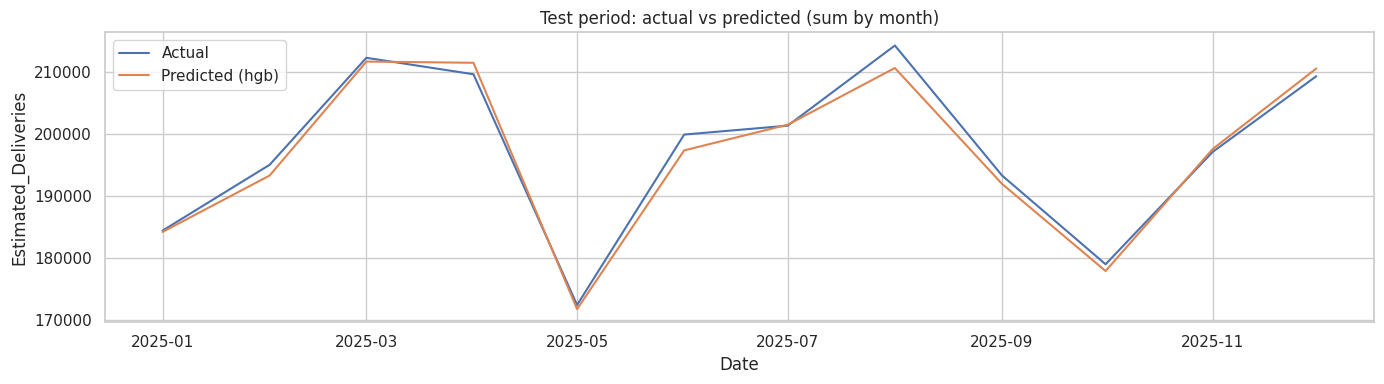

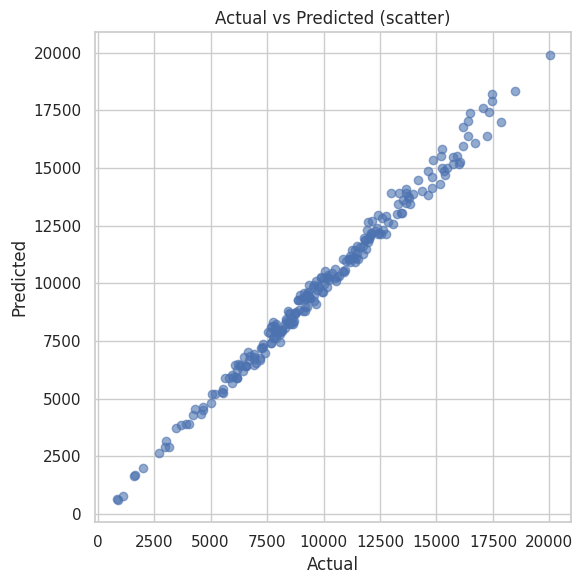

Feature importance not available for this model/preprocessor combination.


In [13]:
# Plot predictions over time
# Aggregate actual vs predicted by month for interpretability
best_name = pd.DataFrame(results).sort_values('RMSE').iloc[0]['model']
best_pipe = trained[best_name]

pred_test = best_pipe.predict(X_test)

pred_df = df_test[['Date']].copy()
pred_df['y_true'] = y_test.values
pred_df['y_pred'] = pred_test

agg = pred_df.groupby('Date', as_index=False).sum().sort_values('Date')

plt.figure(figsize=(14,4))
plt.plot(agg['Date'], agg['y_true'], label='Actual')
plt.plot(agg['Date'], agg['y_pred'], label=f'Predicted ({best_name})')
plt.title('Test period: actual vs predicted (sum by month)')
plt.xlabel('Date')
plt.ylabel(TARGET)
plt.legend()
plt.tight_layout()
plt.show()

# Actual vs Predicted scatter
plt.figure(figsize=(6,6))
plt.scatter(y_test, pred_test, alpha=0.6)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted (scatter)')
plt.tight_layout()
plt.show()

# Feature importance (top 10) for the best model
pre = best_pipe.named_steps['preprocess']
model = best_pipe.named_steps['model']
try:
    feature_names = pre.get_feature_names_out()
except Exception:
    feature_names = None

importances = None
if hasattr(model, 'feature_importances_'):
    importances = model.feature_importances_
elif hasattr(model, 'coef_'):
    importances = np.abs(model.coef_)

if feature_names is not None and importances is not None and len(feature_names) == len(importances):
    fi = (pd.Series(importances, index=feature_names)
            .sort_values(ascending=False)
            .head(10)
            .sort_values())
    plt.figure(figsize=(8,4))
    plt.barh(fi.index, fi.values)
    plt.title(f'Top 10 Feature Importance ({best_name})')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
else:
    print('Feature importance not available for this model/preprocessor combination.')


## 5) Hyperparameter Tuning (TimeSeriesSplit)

We tune the best-performing family using time-series cross-validation.
We'll use **RandomizedSearchCV** with `TimeSeriesSplit` on the training set.

In [14]:
# Choose a model family to tune (usually HGB performs well)
# HGB
base = HistGradientBoostingRegressor(random_state=42)
pipe = Pipeline(steps=[('preprocess', preprocess), ('model', base)])

# Time series CV: split by chronological order
order = df_train.sort_values('Date').index
X_train_ord = X_train.loc[order]
y_train_ord = y_train.loc[order]

tscv = TimeSeriesSplit(n_splits=5)

param_distributions = {
    'model__learning_rate': np.linspace(0.02, 0.2, 10),
    'model__max_depth': [2, 3, 4, 6, None],
    'model__max_leaf_nodes': [15, 31, 63, 127],
    'model__min_samples_leaf': [10, 20, 30, 50, 80],
    'model__l2_regularization': [0.0, 0.01, 0.1, 1.0],
}

search = RandomizedSearchCV(
    pipe,
    param_distributions=param_distributions,
    n_iter=25,
    scoring='neg_root_mean_squared_error',
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

search.fit(X_train_ord, y_train_ord)
print('Best CV RMSE:', -search.best_score_)
print('Best params:', search.best_params_)

best_tuned = search.best_estimator_

tuned_pred = best_tuned.predict(X_test)

pd.DataFrame([eval_regression('hgb_tuned', y_test, tuned_pred)])


Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best CV RMSE: 432.79893841044196
Best params: {'model__min_samples_leaf': 10, 'model__max_leaf_nodes': 31, 'model__max_depth': None, 'model__learning_rate': np.float64(0.14), 'model__l2_regularization': 0.01}


,model,MAE,RMSE,MAPE,R2
0,hgb_tuned,255.543344,334.669009,0.027763,0.991715


In [15]:
# Save the tuned model
OUT_MODEL = 'deliveries_regressor.joblib'
joblib.dump(best_tuned, OUT_MODEL)
print('Saved:', OUT_MODEL)


Saved: deliveries_regressor.joblib


## 6) ML Forecast (Next 12 Months)

We generate a simple **next-12-month** forecast using the best tuned ML model.
Future exogenous features (price/production/etc.) are **carried forward** from the last observed month per (Region, Model).


Last observed month: 2025-12-01
Forecast horizon: 2026-01-01 -> 2026-12-01


,Date,Forecast_Deliveries,Region,Model
0,2026-01-01,7356.622713,Asia,Cybertruck
1,2026-02-01,7345.503925,Asia,Cybertruck
2,2026-03-01,7367.161915,Asia,Cybertruck
3,2026-04-01,7336.149572,Asia,Cybertruck
4,2026-05-01,7324.159740,Asia,Cybertruck


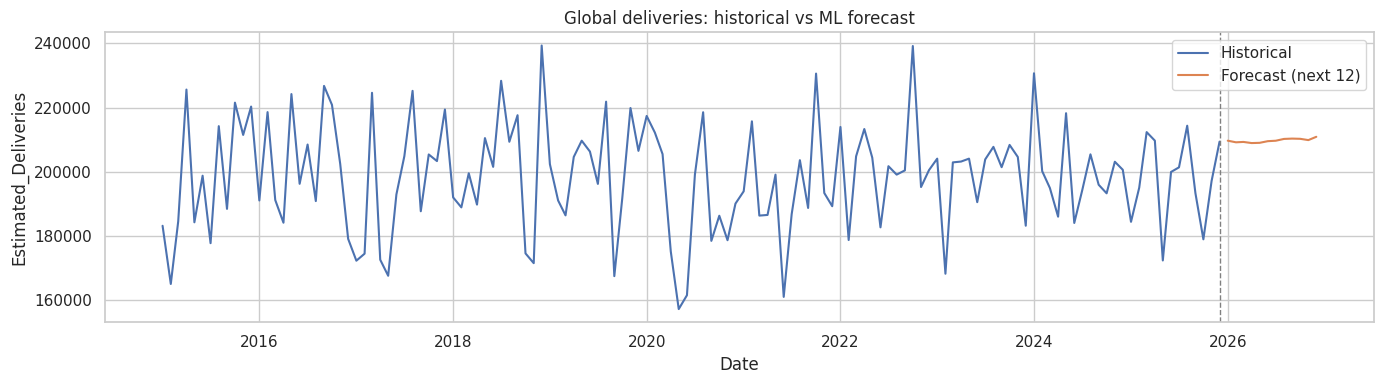

In [16]:
# Train the best tuned model on ALL available rows
best_forecast_model = best_tuned.fit(df[feature_cols], df[TARGET])

# Build future months (next 12)
last_date = pd.to_datetime(df['Date'].max())
future_dates = pd.date_range(last_date + pd.offsets.MonthBegin(1), periods=12, freq='MS')
print('Last observed month:', last_date.date())
print('Forecast horizon:', future_dates[0].date(), '->', future_dates[-1].date())

# Columns needed for feature generation
lag_cols = [c for c in feature_cols if c.startswith(f'{TARGET}_lag')]
roll_cols = [c for c in feature_cols if c.startswith(f'{TARGET}_rollmean')]
time_cols = [c for c in ['month_sin','month_cos','quarter','time_idx','Year','Month'] if c in feature_cols]
base_exog_cols = [c for c in feature_cols if c not in (lag_cols + roll_cols + time_cols) and c not in [TARGET]]

def _compute_time_features(d):
    month = d.month
    out = {}
    if 'Year' in time_cols: out['Year'] = d.year
    if 'Month' in time_cols: out['Month'] = d.month
    if 'month_sin' in time_cols: out['month_sin'] = float(np.sin(2*np.pi*month/12))
    if 'month_cos' in time_cols: out['month_cos'] = float(np.cos(2*np.pi*month/12))
    if 'quarter' in time_cols: out['quarter'] = int(((month-1)//3)+1)
    if 'time_idx' in time_cols: out['time_idx'] = int(pd.Timestamp(d).value // 10**9)
    return out

def _compute_lag_roll(history_vals):
    feats = {}

    for lag in [1,3,6,12]:
        col = f'{TARGET}_lag{lag}'
        if col in lag_cols:
            feats[col] = history_vals[-lag] if len(history_vals) >= lag else np.nan

    for win in [3,6,12]:
        col = f'{TARGET}_rollmean{win}'
        if col in roll_cols:
            feats[col] = float(np.mean(history_vals[-win:])) if len(history_vals) >= win else np.nan
    return feats

# Recursive forecasting per (Region, Model) group
forecast_rows = []
group_cols = GROUP_KEYS if GROUP_KEYS else []
grouped = df.groupby(group_cols) if group_cols else [((), df)]

for gkey, gdf in grouped:
    gdf = gdf.sort_values('Date')

    last_row = gdf.iloc[-1]
    exog = {c: last_row[c] for c in base_exog_cols if c in gdf.columns}

    hist = gdf[TARGET].tolist()

    for d in future_dates:
        row = {}

        if group_cols:
            if not isinstance(gkey, tuple):
                gkey = (gkey,)
            for col, val in zip(group_cols, gkey):
                row[col] = val

        row.update(exog)
        row.update(_compute_time_features(pd.Timestamp(d)))
        row.update(_compute_lag_roll(hist))

        Xf = pd.DataFrame([row], columns=feature_cols)
        yhat = float(best_forecast_model.predict(Xf)[0])
        hist.append(yhat)

        out = {'Date': pd.Timestamp(d), 'Forecast_Deliveries': yhat}
        for col in group_cols:
            out[col] = row.get(col)
        forecast_rows.append(out)

forecast_df = pd.DataFrame(forecast_rows)
display(forecast_df.head())

# Plot global historical vs forecast (sum by month)
hist_global = (df.groupby('Date', as_index=False)[TARGET].sum().sort_values('Date'))
fc_global = (forecast_df.groupby('Date', as_index=False)['Forecast_Deliveries'].sum().sort_values('Date'))

plt.figure(figsize=(14,4))
plt.plot(hist_global['Date'], hist_global[TARGET], label='Historical')
plt.plot(fc_global['Date'], fc_global['Forecast_Deliveries'], label='Forecast (next 12)')
plt.axvline(last_date, color='gray', linestyle='--', linewidth=1)
plt.title('Global deliveries: historical vs ML forecast')
plt.xlabel('Date')
plt.ylabel(TARGET)
plt.legend()
plt.tight_layout()
plt.show()


## 6A) ARIMA Forecast (Next 12 Months)

We also try a simple **ARIMA** model on the global monthly deliveries time series.
This is a univariate method (it only uses past deliveries).


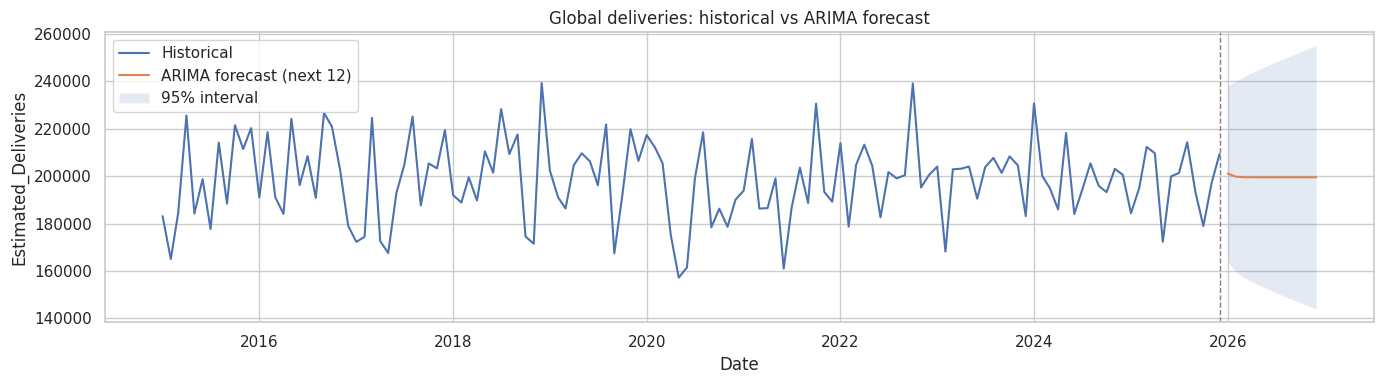

,Date,ARIMA_Forecast_Deliveries
0,2026-01-01,201130.711312
1,2026-02-01,199815.368230
2,2026-03-01,199605.917024
3,2026-04-01,199572.564655
4,2026-05-01,199567.253726
5,2026-06-01,199566.408030
6,2026-07-01,199566.273364
7,2026-08-01,199566.251920
8,2026-09-01,199566.248506
9,2026-10-01,199566.247962


In [17]:
from statsmodels.tsa.arima.model import ARIMA


y = (df.groupby('Date')[TARGET].sum()
       .sort_index()
       .asfreq('MS'))


if y.isna().any():
    y = y.interpolate(limit_direction='both')

train_end = y.index.max()
steps = 12
fc_index = pd.date_range(train_end + pd.offsets.MonthBegin(1), periods=steps, freq='MS')


try:
    arima_res = ARIMA(y, order=(1, 1, 1)).fit()
except Exception:
    arima_res = ARIMA(y, order=(0, 1, 1)).fit()

fc = arima_res.get_forecast(steps=steps)
fc_mean = pd.Series(fc.predicted_mean.values, index=fc_index, name='ARIMA_Forecast')
fc_ci = fc.conf_int()
fc_ci.index = fc_index

plt.figure(figsize=(14,4))
plt.plot(y.index, y.values, label='Historical')
plt.plot(fc_mean.index, fc_mean.values, label='ARIMA forecast (next 12)')
plt.fill_between(fc_ci.index, fc_ci.iloc[:, 0], fc_ci.iloc[:, 1], alpha=0.15, label='95% interval')
plt.axvline(train_end, color='gray', linestyle='--', linewidth=1)
plt.title('Global deliveries: historical vs ARIMA forecast')
plt.xlabel('Date')
plt.ylabel(TARGET)
plt.legend()
plt.tight_layout()
plt.show()

display(pd.DataFrame({'Date': fc_mean.index, 'ARIMA_Forecast_Deliveries': fc_mean.values}))




## Key Findings and Conclusion

* Performed data preprocessing by handling missing values and preparing the dataset for analysis.
* Conducted Exploratory Data Analysis (EDA) to understand trends, distributions, and relationships in the data.
* Applied feature engineering techniques such as date-based, lag, and rolling features to improve model performance.
* Trained and evaluated multiple regression models including Ridge Regression, Random Forest, and HistGradientBoosting Regressor.
* Used RandomizedSearchCV for hyperparameter tuning to optimize model performance.
* Compared models using MAE, RMSE, MAPE, and R² score, where the tuned HistGradientBoosting model achieved the best results.
* Implemented time series forecasting using ARIMA to predict future Tesla deliveries and analyze future trends.
